# Tightness at fixed leakage $\gamma$

The DP-SGD reconstruction-robustness bound $\rho^\star(\gamma)$ depends on the mechanism **only**
through the leakage $\gamma$. At fixed $\gamma$ we sandwich the achievable robustness between the
lower bound and the actual attack:

$$\rho^\star(\gamma)\ \le\ \rho_{\mathrm{blk}}(\gamma)\ \le\ \rho_{\mathrm{cb}}(\gamma),\qquad \rho^\star(\gamma)\ \le\ \rho_{\mathrm{dpsgd}}(\gamma).$$

The single figure below shows, for MNIST / CelebA × pixel / LPIPS:

- **Lower bound $\rho^\star$** (solid blue) — the mechanism-agnostic guarantee (max over the fixed
  grid $G=\{(k,\nu^2)\}$); faint dashed = the same bound as a point estimate with margins dropped.
- **Per-block bound $\rho_{\mathrm{blk}}$** (green dotted) and the **codebook decoder error $\rho_{\mathrm{cb}}$** ($\Diamond$) on the same release.
- **Sub-bit release** ($\star$, $\gamma<1$): randomised-response release on a 2-cell codebook.
- **DP-SGD attack** — the candidate-prior attack of Hayes, Balle & Mahloujifar (NeurIPS 2023, App. G):
  full-dimensional release, per-step mixture likelihood over the shadow set (the target is never a
  candidate), reported as the posterior **mean**. One colour, two configs: **single step** ($q{=}1,T{=}1$,
  $\circ$) and **subsampled** ($q{=}0.02,T{=}100$, $\Box$); on the LPIPS panels the open $\times$ is the
  secondary image-output (pre-image of $\hat\Phi$). Earlier attacks (Wiener, gradient$=$input) are retired.

Every mean attack marker sits above the bound at every $\gamma$ (*"Both mean errors remain above the same bound"*, Sec. 6).

In [1]:
import warnings   # known, benign library warnings (they would print local install paths into the outputs):
warnings.filterwarnings("ignore", message="Optimal order is the largest alpha")   # opacus's PRV accountant sizes its mesh with an RDP bound
warnings.filterwarnings("ignore", message="The parameter 'pretrained' is deprecated")   # inside the lpips package
warnings.filterwarnings("ignore", message="Arguments other than a weight enum")         # inside the lpips package
%matplotlib inline
import glob, json, math, os, sys
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"results").exists() else Path.cwd().parent
FIG_DIR = ROOT / "figures"; FIG_DIR.mkdir(exist_ok=True)   # every figure, under the name the paper includes
TAB_DIR = ROOT / "tables"; TAB_DIR.mkdir(exist_ok=True)
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
from src.privacy.gamma import gamma_prv_mean
from src.privacy.accounting import compute_epsilon_prv
from src.bound.rho import load_bound, rho_curve
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "font.size": 9, "figure.dpi": 130})
LN2 = math.log(2.0)
C_BOUND="#0072B2"; C_PB="#7B3294"; C_KM="#D55E00"; C_TC="#B8860B"; C_DP="#E41A1C"; C_W="#009E73"; C_LW="#8B0000"
N_TRAIN = {"mnist": 50000, "celeba": 45000, "celeba_multi8": 45000}
def gam_prv_bits(nm): return float(gamma_prv_mean(1, 1.0, nm)) / LN2
def eps_of_nm(nm, ds): return compute_epsilon_prv(nm, N_TRAIN.get(ds, 50000)**-1.1, 1.0, 1) if nm > 0 else float("nan")
def J(f):
    p = ROOT/f"results/tightness/{f}"; return json.load(open(p)) if p.exists() else None
def floor(ds, rep):                       # the bound rho*(gamma) and its point estimate, on the figures' gamma grid
    c = rho_curve(load_bound(ds, rep)["pairs"])
    return c["gamma_bits"], c["rho_star"], c["rho_pt"]
print("loaders ready")


loaders ready


In [2]:
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator
GMAX = 100.0; GMIN = 0.05; EPS_TICKS = [0.1, 1, 10, 100]      # top axis: show small epsilon too
C_BAL = "#7B3294"     # balanced codebook: decoder + per-cell floor (shared colour)

def nm_of_gamma_nb(g): return math.sqrt(0.5/(g*LN2))                # single-step (q=1,T=1) noise at gamma
def eps_axis(a, ds):                                               # epsilon axis computed DIRECTLY from sigma (no diffusion-run dependency)
    gg = np.geomspace(GMIN, GMAX, 400); ep = np.array([eps_of_nm(nm_of_gamma_nb(g), ds) for g in gg])
    xs, ls = [], []
    for tgt in EPS_TICKS:
        i = int(np.argmin(np.abs(ep - tgt)))
        if GMIN <= gg[i] <= GMAX and gg[i] not in xs and abs(ep[i] - tgt) < 0.4*tgt:      # only place a tick a gamma actually hits
            xs.append(float(gg[i])); ls.append(f"{tgt:g}")
    sx = a.twiny(); sx.set_xscale("log"); sx.set_xlim(GMIN, GMAX)
    sx.xaxis.set_minor_locator(NullLocator())
    sx.xaxis.set_major_locator(FixedLocator(xs)); sx.xaxis.set_major_formatter(FixedFormatter(ls))
    sx.tick_params(axis="x", labelsize=7); sx.set_xlabel(r"$\varepsilon$", fontsize=8)

def pcbal(ds, rep):
    d = J(f"percell_k1bal_{ds}_{rep}.json")
    if not d: return None
    mn = str(min(d["NU2"])); rows = sorted(d["rows"], key=lambda r: r["R"])
    def band(r):
        pn = r["per_nu"][mn]
        return (abs(math.sqrt(max(0.0, pn["rho2_H1"])) - math.sqrt(max(0.0, pn["rho2_H2"])))
                if pn["rho2_H1"] is not None else 0.0)
    return dict(
        R=np.array([r["R"] for r in rows]),
        floor=np.array([math.sqrt(max(0.0, r["per_nu"][mn]["rho2_full"])) for r in rows]),
        band=np.array([band(r) for r in rows]),
        blk=np.array([r["rho_blk_N0"] for r in rows]),                                   # per-block relaxation rho_blk (tab:tightness)
        bdec=np.array([r["bal_dec_target"] for r in rows]), bdse=np.array([r["bal_dec_se"] for r in rows]))

def subbit(ds, rep):     # sub-bit randomised-response release on a 2-cell codebook (gamma < 1)
    d = J(f"subbit_{ds}_{rep}.json")
    if not d: return None
    r = sorted(d["rows"], key=lambda x: x["gamma"])
    return dict(g=np.array([x["gamma"] for x in r]), att=np.array([x["attack"] for x in r]),
                se=np.array([x["attack_se"] for x in r]), cell=np.array([x["per_cell"] for x in r]),
                blk=np.array([x["per_block"] for x in r]))

print("helpers ready")

helpers ready


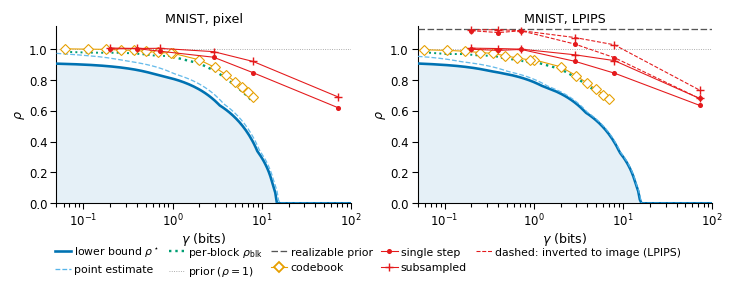

saved figures/tightness_mnist.pdf


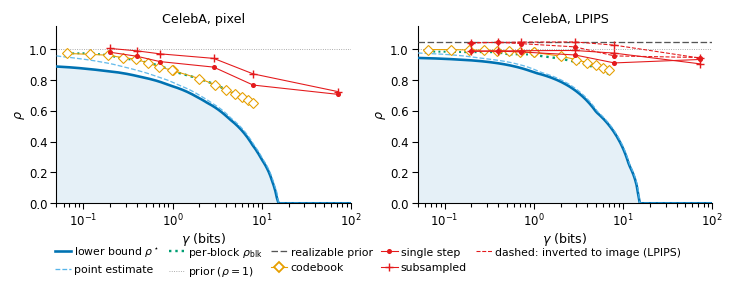

saved figures/tightness_celeba.pdf


In [3]:
# ===== FULL-DIMENSIONAL shadow posterior-mean (SPM) attack (Hayes et al. 2023, App. G; posterior mean) — the paper's DP-SGD attack =====
# Release in full input space G_t = 1_t a(u*) u* + sigma C xi_t (xi_t ~ N(0,I_d)); per-step App. G mixture likelihood
# over the shadow set (candidate NOT the target); output = posterior MEAN (arg-max stored). CelebA 44k / MNIST 58k.
# Colour scheme: FLOORS (lower bound / point-estimate / per-block relaxation) in COOL colours; ATTACKS (codebook, incl. its sub-bit
# randomised-response extension, one series style / DP-SGD) in
# WARM colours. DP-SGD markers: dots = single step, pluses = subsampled; solid = feature output, dashed = image output. LPIPS panels also show the
# realizable prior (best prior-only image output) as a grey baseline.
C_PE   = "#56B4E9"    # point-estimate floor (cool)
C_BLK  = "#009E73"    # per-block relaxation rho_blk (cool)
C_CODE = "#E69F00"    # balanced-codebook decoder attack (warm)
C_DP   = "#E41A1C"    # DP-SGD attacks (warm)
C_PRIOR = "#555555"   # realizable prior baseline (neutral)

def candf(ds, rep):
    try: return json.load(open(ROOT / f"results/tightness_spm/spm_{ds}_{rep}_base.json"))
    except Exception: return None

def realizable_rho(ds):                                                                       # prior-only image output on the rho scale
    try:
        d = json.load(open(ROOT / f"results/tightness/realizable_prior_{ds}.json"))
        return d["realizable_prior_sqrt_lpips"] / candf(ds, "lpips")["denom_a"]
    except Exception: return None

def single_img(ds):                                                                          # single-step LPIPS image output
    try: return json.load(open(ROOT / f"results/tightness_spm/spm_{ds}_lpips_single_img.json"))
    except Exception: return None

def _series(dc, key):                                                                        # (gamma, rho, se) sorted, in range
    gg = np.array([r["gamma"] for r in dc[key]]); o = np.argsort(gg)
    gg = gg[o]; rr = np.array([r["rho"] for r in dc[key]])[o]; se = np.array([r.get("rho_se", 0.0) for r in dc[key]])[o]
    m = (gg >= GMIN) & (gg <= GMAX); return gg[m], rr[m], se[m]

def panel_candf(a, ds, rep, title, SC=1.0):
    """One tightness panel. SC scales line widths / marker sizes (0.6 for the compact paper figure)."""
    # ---- floors: COOL colours ----
    g, rc, rp = floor(ds, rep); mfl = g <= GMAX
    a.plot(g[mfl], rc[mfl], "-", color=C_BOUND, lw=2.4*SC, zorder=5); a.fill_between(g[mfl], 0, rc[mfl], color=C_BOUND, alpha=.10, lw=0)
    a.plot(g[mfl], rp[mfl], "--", color=C_PE, lw=1.2*SC, alpha=0.9, zorder=5)
    pb = pcbal(ds, rep)
    if pb:
        R2 = pb["R"]
        a.plot(R2, pb["blk"], ":", color=C_BLK, lw=2.2*SC, zorder=7)                          # per-block relaxation rho_blk (cool)
        a.errorbar(R2, pb["bdec"], yerr=pb["bdse"], fmt="D-", color=C_CODE, mfc="white", ms=6*SC, capsize=2*SC,
                   lw=1.0*SC, elinewidth=1.0*SC, mew=1.0*SC, zorder=8)                        # codebook attack (warm), with curve
    sb = subbit(ds, rep)
    if sb is not None:
        ms = (sb["g"] >= GMIN) & (sb["g"] <= 1.0)
        a.plot(sb["g"][ms], sb["blk"][ms], ":", color=C_BLK, lw=1.8*SC, zorder=6.8)           # per-block relaxation, sub-bit (cool)
        a.errorbar(sb["g"][ms], sb["att"][ms], yerr=sb["se"][ms], fmt="D-", color=C_CODE, mfc="white", ms=6*SC,
                   capsize=2*SC, lw=1.0*SC, elinewidth=1.0*SC, mew=1.0*SC, zorder=8.5)        # codebook below one bit (same style)
    # (no top epsilon axis: it applied to the single-step markers alone)
    # ---- realizable prior (LPIPS only): best prior-only image output, horizontal baseline ----
    if rep == "lpips":
        rpr = realizable_rho(ds)
        if rpr is not None: a.axhline(rpr, color=C_PRIOR, ls=(0, (5, 2)), lw=1.2*SC, zorder=4.5)
    # ---- DP-SGD attacks: one WARM colour; dots = single step, pluses = subsampled; solid = feature, dashed = image ----
    dc = candf(ds, rep)
    if dc:
        gg, rr, se = _series(dc, "single")
        a.plot(gg, rr, "o-", color=C_DP, mfc=C_DP, ms=3.0*SC, lw=1.0*SC, zorder=10)            # no SE bars on the DP-SGD attacks
        gg, rr, se = _series(dc, "subsampled")
        a.plot(gg, rr, "+-", color=C_DP, ms=7.0*SC, mew=1.3*SC, lw=1.0*SC, zorder=9.8)
        if rep == "lpips":
            g2 = np.array([r["gamma"] for r in dc["subsampled"]]); o = np.argsort(g2); g2 = g2[o]
            ri = np.array([r.get("rho_img", np.nan) for r in dc["subsampled"]])[o]
            m = (g2 >= GMIN) & (g2 <= GMAX) & np.isfinite(ri)
            a.plot(g2[m], ri[m], "+--", color=C_DP, ms=7*SC, mew=1.3*SC, lw=1.0*SC, zorder=9.6)   # subsampled, image output
            si = single_img(ds)                                                                   # single-step image output
            if si is not None:
                g3 = np.array([r["gamma"] for r in si["rows"]]); o = np.argsort(g3); g3 = g3[o]
                r3 = np.array([r["rho"] for r in si["rows"]])[o]; m = (g3 >= GMIN) & (g3 <= GMAX)
                a.plot(g3[m], r3[m], "o--", color=C_DP, mfc=C_DP, ms=3.0*SC, lw=1.0*SC, zorder=9.7)
    a.axhline(1, color="#999", ls=":", lw=.8*SC); a.set_xscale("log"); a.set_xlim(GMIN, GMAX); a.set_ylim(0, 1.15)
    a.set_xlabel(r"$\gamma$ (bits)", labelpad=1); a.set_ylabel(r"$\rho$", labelpad=1); a.set_title(title, pad=2)


# One compact figure per dataset (pixel | LPIPS), legend underneath in 5 columns x 2 rows, 5.5 x 2.1 in in total:
# figures/tightness_{mnist,celeba}.pdf. Image-output curves share one line-style key (dashed).
SC = 0.6
hf = [Line2D([], [], color=C_BOUND, lw=2.4*SC, label=r"lower bound $\rho^\star$"),
      Line2D([], [], color=C_PE, lw=1.2*SC, ls="--", label="point estimate"),
      Line2D([], [], color=C_BLK, lw=2.2*SC, ls=":", label=r"per-block $\rho_{\mathrm{blk}}$"),
      Line2D([], [], color="#999", lw=.8*SC, ls=":", label=r"prior ($\rho=1$)"),
      Line2D([], [], color=C_PRIOR, lw=1.2*SC, ls=(0, (5, 2)), label="realizable prior"),
      Line2D([], [], color=C_CODE, marker="D", mfc="white", ms=6*SC, lw=1.0*SC, label="codebook"),
      Line2D([], [], color=C_DP, marker="o", ms=3.0*SC, lw=1.0*SC, label="single step"),
      Line2D([], [], color=C_DP, marker="+", ms=7*SC, mew=1.3*SC, lw=1.0*SC, label="subsampled"),
      Line2D([], [], color=C_DP, ls="--", lw=1.0*SC, label="dashed: inverted to image (LPIPS)")]
with plt.rc_context({"font.size": 7, "axes.titlesize": 7, "axes.labelsize": 7, "xtick.labelsize": 6.5,
                     "ytick.labelsize": 6.5, "legend.fontsize": 6, "xtick.major.pad": 1.5, "ytick.major.pad": 1.5,
                     "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6}):
    for ds, dname in [("mnist", "MNIST"), ("celeba", "CelebA")]:
        figf, axf = plt.subplots(1, 2, figsize=(5.5, 2.1))
        panel_candf(axf[0], ds, "pixel", f"{dname}, pixel", SC=SC)
        panel_candf(axf[1], ds, "lpips", f"{dname}, LPIPS", SC=SC)
        figf.tight_layout(pad=0.2, w_pad=1.0, rect=[0, 0.12, 1, 1])
        figf.legend(handles=hf, loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=5, frameon=False,
                    columnspacing=0.8, handletextpad=0.3, handlelength=1.5, borderaxespad=0.0)
        figf.savefig(FIG_DIR / f"tightness_{ds}.pdf", bbox_inches="tight", pad_inches=0.02)
        plt.show(); print(f"saved figures/tightness_{ds}.pdf")


## Paper claims backed by this notebook (beyond the figure)
Each cell prints the numbers a sentence or table quotes (paper location in the heading) and writes the LaTeX tables to
`tables/`. `CHECK` lines test a qualitative claim and print `TRUE`/`FALSE`; `FALSE` means the code no longer
reproduces a statement of the final paper. Panels: MNIST/CelebA × pixel/LPIPS.

In [4]:
from src.bound import rho as R
PANELS = [("mnist", "pixel"), ("celeba", "pixel"), ("mnist", "lpips"), ("celeba", "lpips")]
PNAME = {"mnist": "MNIST", "celeba": "CelebA", "pixel": "pixel", "lpips": "LPIPS"}
PAPER_GAMMAS = [0.72, 2.89, 8.01, 72.13]

import functools
@functools.lru_cache(maxsize=None)
def bound_pairs(ds, rep):
    return load_bound(ds, rep)["pairs"]

def rho_star(ds, rep, gamma_bits, field="h_lb_bits"):
    """The lower bound rho* of prop:coverage at leakage gamma (bits), computed exactly from the entropy bound."""
    return R.rho_star(gamma_bits * LN2, bound_pairs(ds, rep), field=field)

### tab:attack_results — the attack against the bound
Table 6 and App. `app:exp_attack` *Evaluation*: *"ρ over the 100 targets, bootstrap standard errors between 0.013 and
0.024"* (300 resamples); *"Both mean errors remain above the same bound"* (Sec. 6).

In [5]:
def candrow(ds, rep, cfg, g):
    return next(r for r in candf(ds, rep)[cfg] if abs(r["gamma"] - g) < 1e-9)

print(f"{'panel':<16}{'config':<20}" + "".join(f"{g:>10g}" for g in PAPER_GAMMAS))
for ds, rep in PANELS:
    for cfg, lab in [("single", "q=1"), ("subsampled", "(q,T)=(0.02,100)")]:
        print(f"{ds+' '+rep:<16}{lab:<20}" + "".join(f"{candrow(ds, rep, cfg, g)['rho']:>10.3f}" for g in PAPER_GAMMAS))
    print(f"{'':<16}{'bound':<20}" + "".join(f"{rho_star(ds, rep, g)['rho_star']:>10.3f}" for g in PAPER_GAMMAS))

TAB6 = [("mnist", "pixel"), ("mnist", "lpips"), ("celeba", "pixel"), ("celeba", "lpips")]   # Table 6's row order
L = [r"\begin{table}[htbp]", r"    \centering\small", r"    \begin{tabular}{l l " + "c " * len(PAPER_GAMMAS) + "}", r"        \toprule",
     r"        & $\gamma$ (bits) & " + " & ".join(f"${g:g}$" for g in PAPER_GAMMAS) + r" \\", r"        \midrule"]
for i, (ds, rep) in enumerate(TAB6):
    L.append(rf"        {PNAME[ds]}, {PNAME[rep]} & $q=1$ & " + " & ".join(f"${candrow(ds, rep, 'single', g)['rho']:.3f}$" for g in PAPER_GAMMAS) + r" \\")
    L.append(r"                      & $(q,T)=(0.02,100)$ & " + " & ".join(f"${candrow(ds, rep, 'subsampled', g)['rho']:.3f}$" for g in PAPER_GAMMAS) + r" \\")
    L.append(r"                      & bound & " + " & ".join(f"${rho_star(ds, rep, g)['rho_star']:.3f}$".replace("$0.000$", "$0$") for g in PAPER_GAMMAS) + r" \\")
    L.append(r"        \midrule" if i < len(TAB6) - 1 else r"        \bottomrule")
ses = [candrow(ds, rep, cfg, g)["rho_se"] for ds, rep in PANELS for cfg in ("single", "subsampled") for g in PAPER_GAMMAS]
L += [r"    \end{tabular}",
      rf"    \caption{{The attack against the bound: $\rho$ over the $100$ targets, bootstrap standard errors between "
      rf"${min(ses):.3f}$ and ${max(ses):.3f}$.}}",
      r"    \label{tab:attack_results}", r"\end{table}", ""]
(TAB_DIR / "attack_results.tex").write_text("\n".join(L)); print("\n".join(L))

print(f"\nbootstrap SE over the table cells: {min(ses):.4f} .. {max(ses):.4f}   (paper caption: 0.013 .. 0.024)")
print(f"CHECK SE range 0.013-0.024: {'TRUE ' if round(min(ses),3) == 0.013 and round(max(ses),3) == 0.024 else 'FALSE'}")

# bound never crossed: every attack marker (every gamma run, both configs, LPIPS image output too) >= rho*
viol = []
for ds, rep in PANELS:
    for cfg in ("single", "subsampled"):
        for r in candf(ds, rep)[cfg]:
            fl = rho_star(ds, rep, r["gamma"])["rho_star"]
            for key in ("rho", "rho_img"):
                if key in r and r[key] < fl: viol.append((ds, rep, cfg, key, r["gamma"], r[key], fl))
print(f"CHECK both mean errors remain above the bound (every attack marker): {'TRUE ' if not viol else 'FALSE'} {viol}")

panel           config                    0.72      2.89      8.01     72.13
mnist pixel     q=1                      0.987     0.948     0.848     0.620
mnist pixel     (q,T)=(0.02,100)         1.006     0.984     0.921     0.690
                bound                    0.831     0.673     0.397     0.000
celeba pixel    q=1                      0.920     0.884     0.768     0.707
celeba pixel    (q,T)=(0.02,100)         0.970     0.941     0.840     0.725
                bound                    0.789     0.628     0.373     0.000
mnist lpips     q=1                      0.999     0.922     0.845     0.636
mnist lpips     (q,T)=(0.02,100)         1.001     0.964     0.926     0.681
                bound                    0.816     0.653     0.396     0.000
celeba lpips    q=1                      0.983     0.963     0.911     0.933
celeba lpips    (q,T)=(0.02,100)         0.991     0.992     0.975     0.906
                bound                    0.878     0.734     0.459     0.000

### Subsampling cost, the 72-bit CelebA markers, and the attack set-up
App. `app:exp_attack` *Evaluation*: *"Subsampling weakens the attack at matched γ by up to 0.08 in ρ (paired
differences −0.03 to +0.08; it is slightly stronger only on CelebA LPIPS at 72 bits)"*; *"at 72 bits the CelebA
markers stop at 0.71–0.73 (pixel) and 0.91–0.93 (LPIPS), over the two configurations"*. Set-up: shadow sets of
58,000 (MNIST) and 44,000 (CelebA), 100 targets, C = 0.3 with every candidate gradient clipped.

In [6]:
print(f"{'panel':<16}" + "".join(f"{g:>16g}" for g in PAPER_GAMMAS) + "   (subsampled - single, paired SE)")
diffs = []
for ds, rep in PANELS:
    cells = []
    for g in PAPER_GAMMAS:
        b = candrow(ds, rep, "subsampled", g); diffs.append(b["paired_diff"])
        cells.append(f"{b['paired_diff']:+.3f}({b['paired_se']:.3f})")
    print(f"{ds+' '+rep:<16}" + "".join(f"{c:>16}" for c in cells))
print(f"range of subsampled - single over the table: {min(diffs):+.3f} .. {max(diffs):+.3f}")
neg = [(ds, rep, g) for ds, rep in PANELS for g in PAPER_GAMMAS if candrow(ds, rep, "subsampled", g)["paired_diff"] < 0]
print(f"CHECK paired differences -0.03 to +0.08: "
      f"{'TRUE ' if round(min(diffs), 2) == -0.03 and round(max(diffs), 2) == 0.08 else 'FALSE'}")
print(f"CHECK subsampling is stronger (negative difference) only on CelebA LPIPS at 72 bits: "
      f"{'TRUE ' if neg == [('celeba', 'lpips', 72.13)] else 'FALSE'} {neg}")

print("\nCelebA at gamma = 72.13 bits:")
from decimal import Decimal, ROUND_HALF_UP
r2 = lambda v: float(Decimal(f"{v:.3f}").quantize(Decimal("0.01"), ROUND_HALF_UP))   # Table 6's 3 decimals, to 2
stop = {}
for rep in ("pixel", "lpips"):
    s, b = candrow("celeba", rep, "single", 72.13), candrow("celeba", rep, "subsampled", 72.13)
    stop[rep] = (r2(min(s["rho"], b["rho"])), r2(max(s["rho"], b["rho"])))
    print(f"  {rep:<6} single(q=1) = {s['rho']:.3f}   subsampled = {b['rho']:.3f}"
          + (f"   subsampled image output = {b['rho_img']:.3f}" if "rho_img" in b else ""))

print(f"CHECK CelebA markers at 72 bits stop at 0.71-0.73 (pixel) and 0.91-0.93 (LPIPS): "
      f"{'TRUE ' if stop == {'pixel': (0.71, 0.73), 'lpips': (0.91, 0.93)} else 'FALSE'} {stop}")

print("\nattack set-up (from the attack run files):")
for ds, rep in PANELS:
    d = candf(ds, rep)
    print(f"  {ds:<7}{rep:<6} candidates(D_shadow)={d['ncand']:>6}  targets={d['n_targets']}  C={d['C']}  "
          f"fraction of candidates clipped={d['clip_cand']:.4f}  q_sub={d['q']} T_sub={d['T']}  attack={d['attack']}")
tgt_clip = all(candf(ds, rep)["clip_cand"] == 1.0 for ds, rep in PANELS)
print(f"CHECK every candidate gradient is clipped at C=0.3: {'TRUE ' if tgt_clip else 'FALSE'}")

panel                       0.72            2.89            8.01           72.13   (subsampled - single, paired SE)
mnist pixel        +0.019(0.006)   +0.036(0.012)   +0.073(0.022)   +0.070(0.016)
celeba pixel       +0.050(0.017)   +0.057(0.019)   +0.073(0.022)   +0.018(0.018)
mnist lpips        +0.002(0.010)   +0.042(0.017)   +0.081(0.026)   +0.045(0.016)
celeba lpips       +0.008(0.003)   +0.029(0.005)   +0.064(0.009)   -0.028(0.014)
range of subsampled - single over the table: -0.028 .. +0.081
CHECK paired differences -0.03 to +0.08: TRUE 
CHECK subsampling is stronger (negative difference) only on CelebA LPIPS at 72 bits: TRUE  [('celeba', 'lpips', 72.13)]

CelebA at gamma = 72.13 bits:
  pixel  single(q=1) = 0.707   subsampled = 0.725
  lpips  single(q=1) = 0.933   subsampled = 0.906   subsampled image output = 0.943
CHECK CelebA markers at 72 bits stop at 0.71-0.73 (pixel) and 0.91-0.93 (LPIPS): TRUE  {'pixel': (0.71, 0.73), 'lpips': (0.91, 0.93)}

attack set-up (from the attack 

### tab:tightness (Table 8) — the chain ρ* ≤ ρ_blk ≤ ρ_cb, and its gaps
App. `app:exp_compressor` and Sec. 6: *"the first gap is 0.10–0.33 in ρ and the second at most 0.03"* (checked on
the rows of Table 8, R ≥ 1), the second gap *"slightly negative, within standard error, on CelebA pixels at
R = 3–5"*, *"the realised H(Q) is within 0.07 bits of R"*, and the `tab:chain` settings (k = 1, ν² = 0.2, 20 records
per cell, R ≤ 8 pixel / R ≤ 7 LPIPS). ρ* is computed exactly at every R (no missing rates). The figure's dotted
green line and the table's ρ_blk are both the per-block bound of Prop. `prop:block_leakage` (`rho_blk_N0`); the
per-cell relaxation (`rho_N0`) is printed as a diagnostic.

In [7]:
def chain(ds, rep):
    d = J(f"percell_k1bal_{ds}_{rep}.json"); out = []
    for r in sorted(d["rows"], key=lambda r: r["R"]):
        rs = rho_star(ds, rep, float(r["R"]))["rho_star"]
        out.append(dict(R=r["R"], rho_star=rs, rho_blk=r["rho_blk_N0"], rho_cell=r["rho_N0"],
                        rho_cb=r["bal_dec_target"], se=r["bal_dec_se"], HQ=r["Hhat_bal"]))
    return d, out

def tight_tex(panels, label, caption):
    L = [r"\begin{table}[htbp]", r"    \centering\small", r"    \setlength{\tabcolsep}{5pt}",
         r"    \begin{tabular}{r rr r rr}", r"        \toprule",
         r"        $R$ & $\rho^\star$ & $\rho_{\mathrm{blk}}$ & $\rho_{\mathrm{cb}}$ (SE) & $\rho_{\mathrm{blk}}-\rho^\star$ & $\rho_{\mathrm{cb}}-\rho_{\mathrm{blk}}$ \\"]
    for ds, rep in panels:
        L.append(r"        \midrule")
        if len(panels) > 1: L.append(rf"        \multicolumn{{6}}{{l}}{{\emph{{{PNAME[ds]}, {PNAME[rep]}}}}} \\")
        for r in chain(ds, rep)[1]:
            f3 = lambda v: f"{v:.3f}".replace("-0.000", "0.000")          # no negative zero
            L.append(rf"        ${r['R']}$ & ${r['rho_star']:.3f}$ & ${r['rho_blk']:.3f}$ & ${r['rho_cb']:.3f}$ (${r['se']:.3f}$) & "
                     rf"${f3(r['rho_blk']-r['rho_star'])}$ & ${f3(r['rho_cb']-r['rho_blk'])}$ \\")
    L += [r"        \bottomrule", r"    \end{tabular}", rf"    \caption{{{caption}}}", rf"    \label{{{label}}}", r"\end{table}", ""]
    return "\n".join(L)

t1 = tight_tex(PANELS, "tab:tightness",
               r"Values behind \Cref{fig:tightness,fig:tightness_mnist}, one block per panel. Gaps are computed before rounding.")
(TAB_DIR / "tightness.tex").write_text(t1)
print(t1); print("wrote tables/tightness.tex\n")

g1, g2, g2c, hq, allrows = [], [], [], [], {}
print(f"{'panel':<14}{'R':>3}{'rho*':>8}{'rho_blk':>9}{'rho_cell':>9}{'rho_cb':>8}{'SE':>7}{'H(Q)':>7}{'gap1':>8}{'gap2':>8}{'cb-cell':>8}")
for ds, rep in PANELS:
    d, rows = chain(ds, rep); allrows[(ds, rep)] = (d, rows)
    for r in rows:
        g1.append(r["rho_blk"] - r["rho_star"]); g2.append(r["rho_cb"] - r["rho_blk"]); g2c.append(r["rho_cb"] - r["rho_cell"])
        hq.append((abs(r["HQ"] - r["R"]), ds, rep, r["R"]))
        print(f"{ds+' '+rep:<14}{r['R']:>3}{r['rho_star']:>8.3f}{r['rho_blk']:>9.3f}{r['rho_cell']:>9.3f}{r['rho_cb']:>8.3f}"
              f"{r['se']:>7.3f}{r['HQ']:>7.3f}{g1[-1]:>8.3f}{g2[-1]:>8.3f}{g2c[-1]:>8.3f}")
print(f"\nfirst gap  rho_blk - rho*   : {min(g1):.3f} .. {max(g1):.3f}   (paper: 0.10-0.33)")
print(f"second gap rho_cb  - rho_blk: {min(g2):+.3f} .. {max(g2):+.3f}   (paper: at most 0.03)")
print(f"           rho_cb  - rho_cell: {min(g2c):+.3f} .. {max(g2c):+.3f}")
print(f"CHECK first gap 0.10-0.33 over the rows of Table 8: "
      f"{'TRUE ' if round(min(g1), 2) == 0.10 and round(max(g1), 2) == 0.33 else 'FALSE'}")
print(f"CHECK second gap at most 0.03 (to the paper's 2 decimals; max {max(g2):.3f}): {'TRUE ' if round(max(g2), 2) <= 0.03 else 'FALSE'}")
negs = [(ds, rep, r['R']) for (ds, rep) in PANELS for r in chain(ds, rep)[1] if round(r['rho_cb'] - r['rho_blk'], 3) < 0]
within = all(abs(r['rho_cb'] - r['rho_blk']) <= r['se'] for (ds, rep) in PANELS for r in chain(ds, rep)[1] if r['rho_cb'] < r['rho_blk'])
print(f"CHECK second gap negative only on CelebA pixels at R = 3-5, within one SE: "
      f"{'TRUE ' if negs and all(d == 'celeba' and p == 'pixel' and 3 <= R <= 5 for d, p, R in negs) and within else 'FALSE'} {negs}")
w = max(hq)
print(f"max |H(Q) - R| = {w[0]:.3f} bits ({w[1]} {w[2]} R={w[3]})")
print(f"CHECK realised H(Q) within 0.07 bits of R: {'TRUE ' if w[0] <= 0.07 else 'FALSE'}")

print("\nper-block / codebook settings (tab:chain):")
for (ds, rep), (d, rows) in allrows.items():
    print(f"  {ds:<7}{rep:<6} k={d['k']}  nu2={d['NU2']}  min records/cell={d['n_min']}  R_max={max(r['R'] for r in rows)}  "
          f"n_est={d['n_est']}  MC draws={d['n_mc']}  J1 identity check pass={d['J1']['pass_']}")

print("\nsub-bit (randomised-response) rows with ordering_ok == False (rho* <= per-block <= attack violated somewhere):")
for ds, rep in PANELS:
    s = J(f"subbit_{ds}_{rep}.json")
    bad = [(round(r["gamma"], 3), r.get("rho_star"), r.get("per_block"), r.get("per_cell"), r.get("attack")) for r in s["rows"] if not r.get("ordering_ok", True)]
    print(f"  {ds:<7}{rep:<6} H(Q) two-cell = {s['HQ']:.3f}   bad rows (gamma, rho*, per_block, per_cell, attack): {bad}")

\begin{table}[htbp]
    \centering\small
    \setlength{\tabcolsep}{5pt}
    \begin{tabular}{r rr r rr}
        \toprule
        $R$ & $\rho^\star$ & $\rho_{\mathrm{blk}}$ & $\rho_{\mathrm{cb}}$ (SE) & $\rho_{\mathrm{blk}}-\rho^\star$ & $\rho_{\mathrm{cb}}-\rho_{\mathrm{blk}}$ \\
        \midrule
        \multicolumn{6}{l}{\emph{MNIST, pixel}} \\
        $1$ & $0.809$ & $0.951$ & $0.975$ ($0.005$) & $0.142$ & $0.023$ \\
        $2$ & $0.739$ & $0.908$ & $0.931$ ($0.005$) & $0.169$ & $0.023$ \\
        $3$ & $0.665$ & $0.859$ & $0.882$ ($0.005$) & $0.194$ & $0.023$ \\
        $4$ & $0.606$ & $0.811$ & $0.834$ ($0.005$) & $0.205$ & $0.023$ \\
        $5$ & $0.558$ & $0.765$ & $0.790$ ($0.005$) & $0.207$ & $0.026$ \\
        $6$ & $0.507$ & $0.728$ & $0.754$ ($0.005$) & $0.220$ & $0.027$ \\
        $7$ & $0.454$ & $0.692$ & $0.721$ ($0.005$) & $0.238$ & $0.029$ \\
        $8$ & $0.397$ & $0.658$ & $0.691$ ($0.005$) & $0.261$ & $0.032$ \\
        \midrule
        \multicolumn{6}{l}{\emph{C

### Binding pair (k*, ν²*) of the plotted bounds, and the grid boundary
App. `app:exp_entropy` *Grid*: *"The selected pair often lies on the boundary of the grid"*. Printed at the
leakages of the tightness figures (the spectrum-level statements are checked in `paper_utility_curves`).

In [8]:
from src.bound.rho import PIXEL_BOUND_DIR, LPIPS_BOUND_DIR
for ds, rep in PANELS:
    c = json.load(open(Path((PIXEL_BOUND_DIR if rep == "pixel" else LPIPS_BOUND_DIR)[ds]) / "entropy_bound.json"))
    K, N = c["grid_k"], c["grid_nu2"]
    gs = sorted(set(PAPER_GAMMAS + [float(R) for R in range(1, 9)]))
    sel = [(g, rho_star(ds, rep, g)) for g in gs]
    ks = [s["k_star"] for _, s in sel if s["k_star"] is not None]
    edge = [f"g={g:g}:" + ",".join(([f"k*={s['k_star']}"] if s["k_star"] == max(K) else []) +
                                   ([f"nu2*={s['nu2_star']:g}"] if s["nu2_star"] in (min(N), max(N)) else []))
            for g, s in sel if s["k_star"] is not None and (s["k_star"] == max(K) or s["nu2_star"] in (min(N), max(N)))]
    print(f"{ds} {rep}: K={K} N={N}")
    print("   " + "  ".join(f"g={g:g}:(k={s['k_star']},nu2={s['nu2_star']})" for g, s in sel))
    print(f"   binding k range over the reported leakages: {min(ks)}..{max(ks)}")
    print(f"   on the grid boundary (k* = max K or nu2* at an end of N): {edge if edge else 'none'}")

mnist pixel: K=[1, 2, 4, 7, 8, 14, 16, 28] N=[0.2, 0.4, 0.8, 1.6, 3.2, 6.4]
   g=0.72:(k=14,nu2=0.8)  g=1:(k=28,nu2=1.6)  g=2:(k=28,nu2=1.6)  g=2.89:(k=28,nu2=1.6)  g=3:(k=28,nu2=1.6)  g=4:(k=28,nu2=0.8)  g=5:(k=28,nu2=0.8)  g=6:(k=28,nu2=0.8)  g=7:(k=28,nu2=0.8)  g=8:(k=28,nu2=0.8)  g=8.01:(k=28,nu2=0.8)  g=72.13:(k=None,nu2=None)
   binding k range over the reported leakages: 14..28
   on the grid boundary (k* = max K or nu2* at an end of N): ['g=1:k*=28', 'g=2:k*=28', 'g=2.89:k*=28', 'g=3:k*=28', 'g=4:k*=28', 'g=5:k*=28', 'g=6:k*=28', 'g=7:k*=28', 'g=8:k*=28', 'g=8.01:k*=28']


celeba pixel: K=[1, 2, 3, 4, 6, 8, 12, 16, 24, 32] N=[0.2, 0.4, 0.8, 1.6, 3.2, 6.4]
   g=0.72:(k=8,nu2=0.4)  g=1:(k=16,nu2=0.8)  g=2:(k=32,nu2=1.6)  g=2.89:(k=24,nu2=0.8)  g=3:(k=24,nu2=0.8)  g=4:(k=24,nu2=0.8)  g=5:(k=32,nu2=0.8)  g=6:(k=32,nu2=0.8)  g=7:(k=32,nu2=0.8)  g=8:(k=24,nu2=0.4)  g=8.01:(k=24,nu2=0.4)  g=72.13:(k=None,nu2=None)
   binding k range over the reported leakages: 8..32
   on the grid boundary (k* = max K or nu2* at an end of N): ['g=2:k*=32', 'g=5:k*=32', 'g=6:k*=32', 'g=7:k*=32']
mnist lpips: K=[1, 2, 4, 8, 16, 32] N=[0.2, 0.4, 0.8, 1.6, 3.2, 6.4]
   g=0.72:(k=32,nu2=3.2)  g=1:(k=32,nu2=3.2)  g=2:(k=32,nu2=1.6)  g=2.89:(k=32,nu2=1.6)  g=3:(k=32,nu2=1.6)  g=4:(k=32,nu2=0.8)  g=5:(k=32,nu2=0.8)  g=6:(k=32,nu2=0.8)  g=7:(k=32,nu2=0.8)  g=8:(k=32,nu2=0.8)  g=8.01:(k=32,nu2=0.8)  g=72.13:(k=None,nu2=None)
   binding k range over the reported leakages: 32..32
   on the grid boundary (k* = max K or nu2* at an end of N): ['g=0.72:k*=32', 'g=1:k*=32', 'g=2:k*=32', 'g=2.89

### Realizable (data-blind image) LPIPS baseline — App. `app:exp_phi`
*"On that scale the image baseline sits slightly above 1 (1.131 on MNIST and 1.045 on CelebA)"*; drawn as the grey
dashed line (legend: "realizable prior") in the LPIPS panels of Figures 3 and 7. Printed with the procedure the code actually used.

In [9]:
for ds in ("mnist", "celeba"):
    d = json.load(open(ROOT / f"results/tightness/realizable_prior_{ds}.json"))
    meta = {k: v for k, v in d.items() if not isinstance(v, (list, dict))}
    print(f"{ds}: realizable rho = {realizable_rho(ds):.3f}   "
          f"(sqrt-LPIPS {d['realizable_prior_sqrt_lpips']:.4f} / sqrt(tr Sigma_Phi) {candf(ds, 'lpips')['denom_a']:.4f})")
    print(f"   run metadata: {meta}")
print("source: scripts/compute_realizable_prior.py")

mnist: realizable rho = 1.131   (sqrt-LPIPS 0.4139 / sqrt(tr Sigma_Phi) 0.3658)
   run metadata: {'dataset': 'mnist', 'n_targets': 100, 'realizable_prior_sqrt_lpips': 0.41386082768440247, 'feature_centroid_sqrt_lpips': 0.36820244789123535}
celeba: realizable rho = 1.045   (sqrt-LPIPS 0.3971 / sqrt(tr Sigma_Phi) 0.3801)
   run metadata: {'dataset': 'celeba', 'n_targets': 100, 'realizable_prior_sqrt_lpips': 0.3971298635005951, 'feature_centroid_sqrt_lpips': 0.3761278986930847}
source: scripts/compute_realizable_prior.py


### fig:sandwich_full — per-target spread behind the attack markers
*"At low leakage a sizeable fraction of individual targets fall below it (9–40% at γ ≤ 0.72 bits, 1–11% at
2.89 bits, at most 3% at 8.01 bits), which the bound permits."*
Per-target ρ_i = ‖error_i‖/√tr Σ̂; the marker is √(mean error²)/√tr Σ̂. Shaded: 10–90th percentile; faint points: every
target. Saved to `figures/tightness_pertarget.{pdf,png}`.

panel         config        gamma  rho(mean)  frac targets below rho*


mnist pixel   single          0.2      1.002                     0.24
mnist pixel   single          0.4      1.004                     0.16
mnist pixel   single         0.72      0.987                     0.13
mnist pixel   single         2.89      0.948                     0.05
mnist pixel   single         8.01      0.848                     0.01
mnist pixel   single        72.13      0.620                     0.00
mnist pixel   subsampled      0.2      1.008                     0.24
mnist pixel   subsampled      0.4      1.005                     0.19
mnist pixel   subsampled     0.72      1.006                     0.11
mnist pixel   subsampled     2.89      0.984                     0.04
mnist pixel   subsampled     8.01      0.921                     0.03
mnist pixel   subsampled    72.13      0.690                     0.00
celeba pixel  single          0.2      0.981                     0.31
celeba pixel  single          0.4      0.954                     0.33
celeba pixel  single

celeba lpips  single          0.2      0.987                     0.40
celeba lpips  single          0.4      0.988                     0.34
celeba lpips  single         0.72      0.983                     0.26
celeba lpips  single         2.89      0.963                     0.03
celeba lpips  single         8.01      0.911                     0.00
celeba lpips  single        72.13      0.933                     0.00
celeba lpips  subsampled      0.2      0.988                     0.40
celeba lpips  subsampled      0.4      0.988                     0.37
celeba lpips  subsampled     0.72      0.991                     0.24
celeba lpips  subsampled     2.89      0.992                     0.01
celeba lpips  subsampled     8.01      0.975                     0.00
celeba lpips  subsampled    72.13      0.906                     0.00


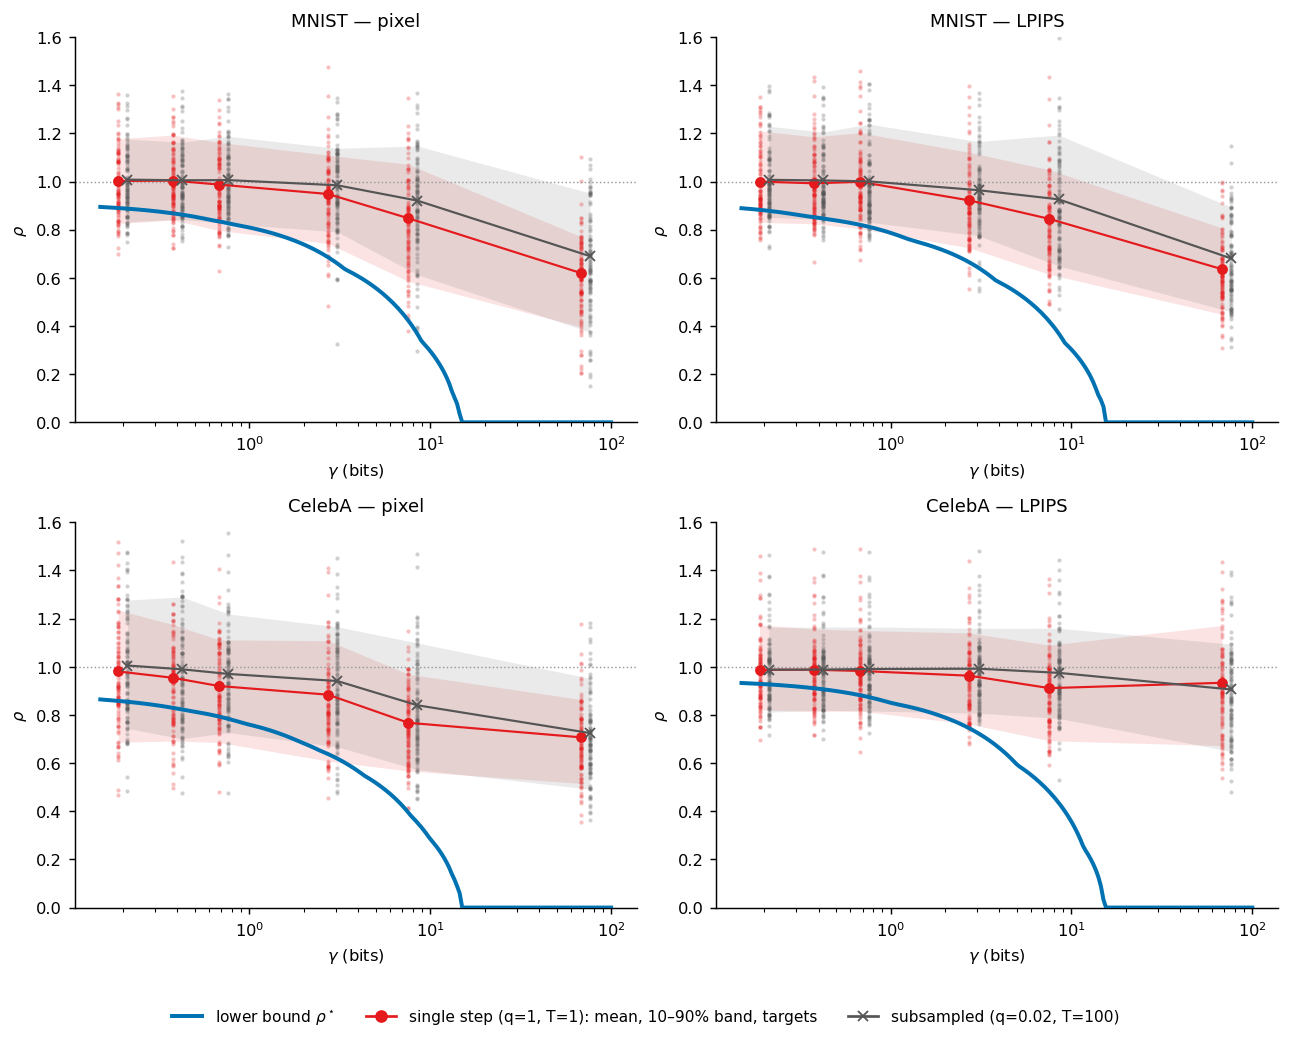

saved figures/tightness_pertarget.pdf


In [10]:
figp, axp = plt.subplots(2, 2, figsize=(10, 8))
print(f"{'panel':<14}{'config':<12}{'gamma':>7}{'rho(mean)':>11}{'frac targets below rho*':>25}")
for a, (ds, rep) in zip(axp.T.ravel(), PANELS):
    dc = candf(ds, rep); den = dc["denom_a"]
    gg = np.geomspace(0.15, 100, 200)
    a.plot(gg, [rho_star(ds, rep, g)["rho_star"] for g in gg], "-", color=C_BOUND, lw=2.2, zorder=5)
    for cfg, col, off, mk in [("single", C_DP, 1 / 1.06, "o"), ("subsampled", "#555555", 1.06, "x")]:
        rows = sorted(dc[cfg], key=lambda r: r["gamma"])
        G = np.array([r["gamma"] for r in rows]); P = [np.sqrt(np.array(r["per_err"])) / den for r in rows]
        lo = [np.percentile(p, 10) for p in P]; hi = [np.percentile(p, 90) for p in P]
        a.fill_between(G * off, lo, hi, color=col, alpha=.12, lw=0)
        for g, p in zip(G, P):
            a.plot(np.full(len(p), g * off), p, ".", color=col, alpha=.18, ms=3)
        a.plot(G * off, [r["rho"] for r in rows], mk + "-", color=col, ms=5, lw=1.2, zorder=8)
        for g, p, r in zip(G, P, rows):
            fl = rho_star(ds, rep, g)["rho_star"]
            print(f"{ds+' '+rep:<14}{cfg:<12}{g:>7g}{r['rho']:>11.3f}{np.mean(p < fl):>25.2f}")
    a.axhline(1, color="#999", ls=":", lw=.8); a.set_xscale("log"); a.set_ylim(0, 1.6)
    a.set_xlabel(r"$\gamma$ (bits)"); a.set_ylabel(r"$\rho$"); a.set_title(f"{PNAME[ds]} — {PNAME[rep]}", fontsize=10)
hp = [Line2D([], [], color=C_BOUND, lw=2.2, label=r"lower bound $\rho^\star$"),
      Line2D([], [], color=C_DP, marker="o", label="single step (q=1, T=1): mean, 10–90% band, targets"),
      Line2D([], [], color="#555555", marker="x", label="subsampled (q=0.02, T=100)")]
figp.tight_layout(rect=[0, 0.05, 1, 1]); figp.legend(handles=hp, loc="lower center", ncol=3, fontsize=8.5, frameon=False)
figp.savefig(FIG_DIR / "tightness_pertarget.pdf", bbox_inches="tight")
plt.show(); print("saved figures/tightness_pertarget.pdf")

### fig:exemplars — what a given ρ looks like (SPM attack, single step)
Reconstructions of 6 fixed held-out targets at 7 leakages; column header = ρ over all 100 targets at that leakage
(from `scripts/tightness_spm.py --exemplar-mode 6`, scheduled by `reproduce/run_all.sh tightness` → `results/tightness_spm/exemplars/`). LPIPS rows show the image output
(feature posterior mean inverted to an image). The paper's *"In pixel space most reconstructed digits are wrong at ρ = 0.85
(γ = 8 bits) and all six are right at ρ = 0.65 (γ = 30 bits)"* is a visual judgement on these panels.

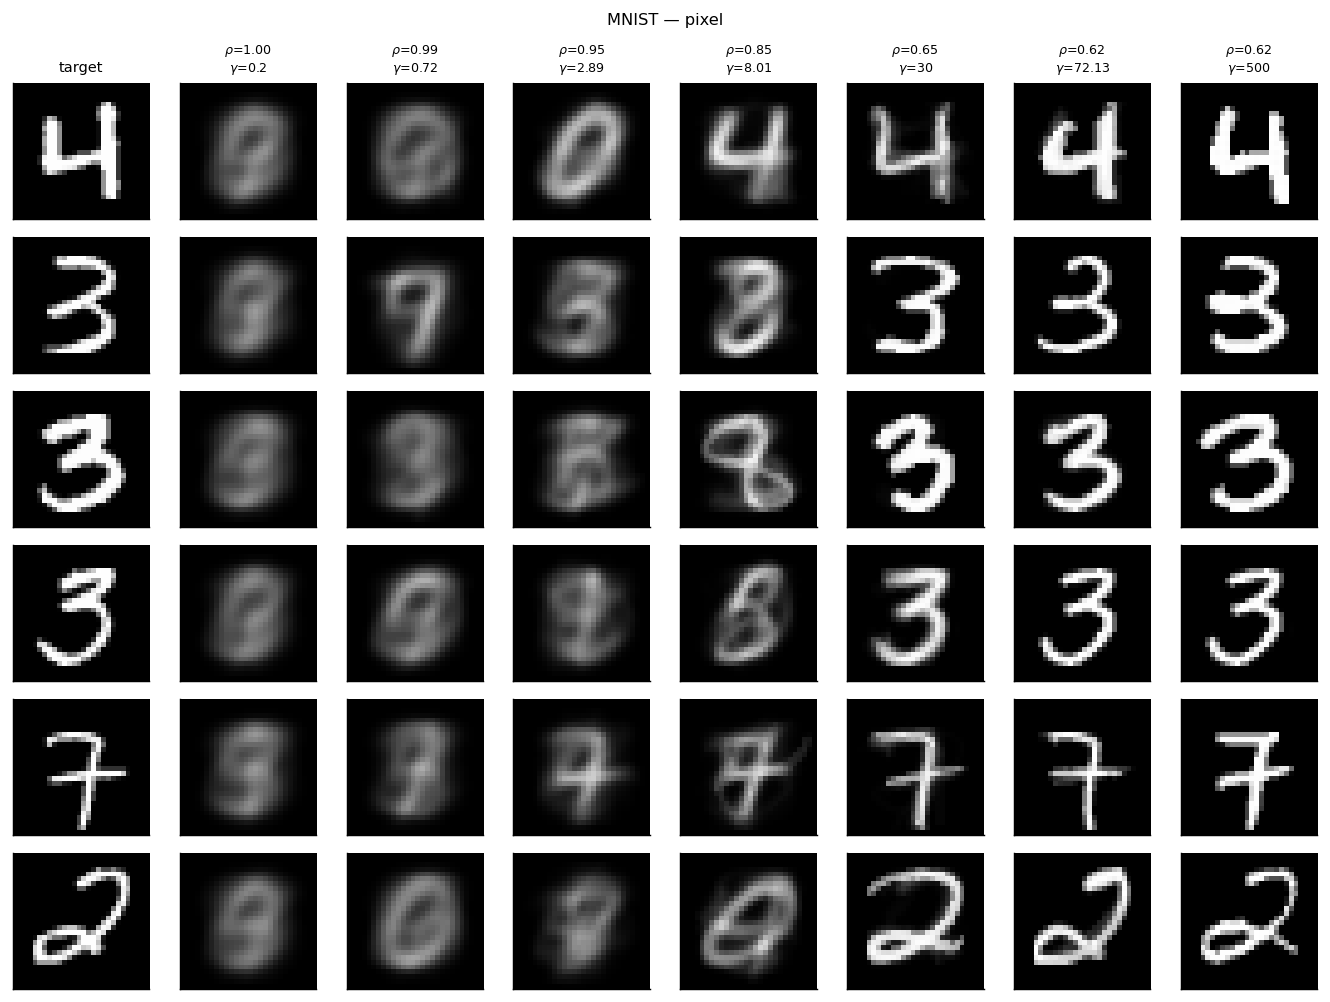

mnist pixel: gamma -> rho: 0.2->1.002, 0.72->0.987, 2.89->0.948, 8.01->0.848, 30->0.650, 72.13->0.620, 500->0.623  (ncand=58000)


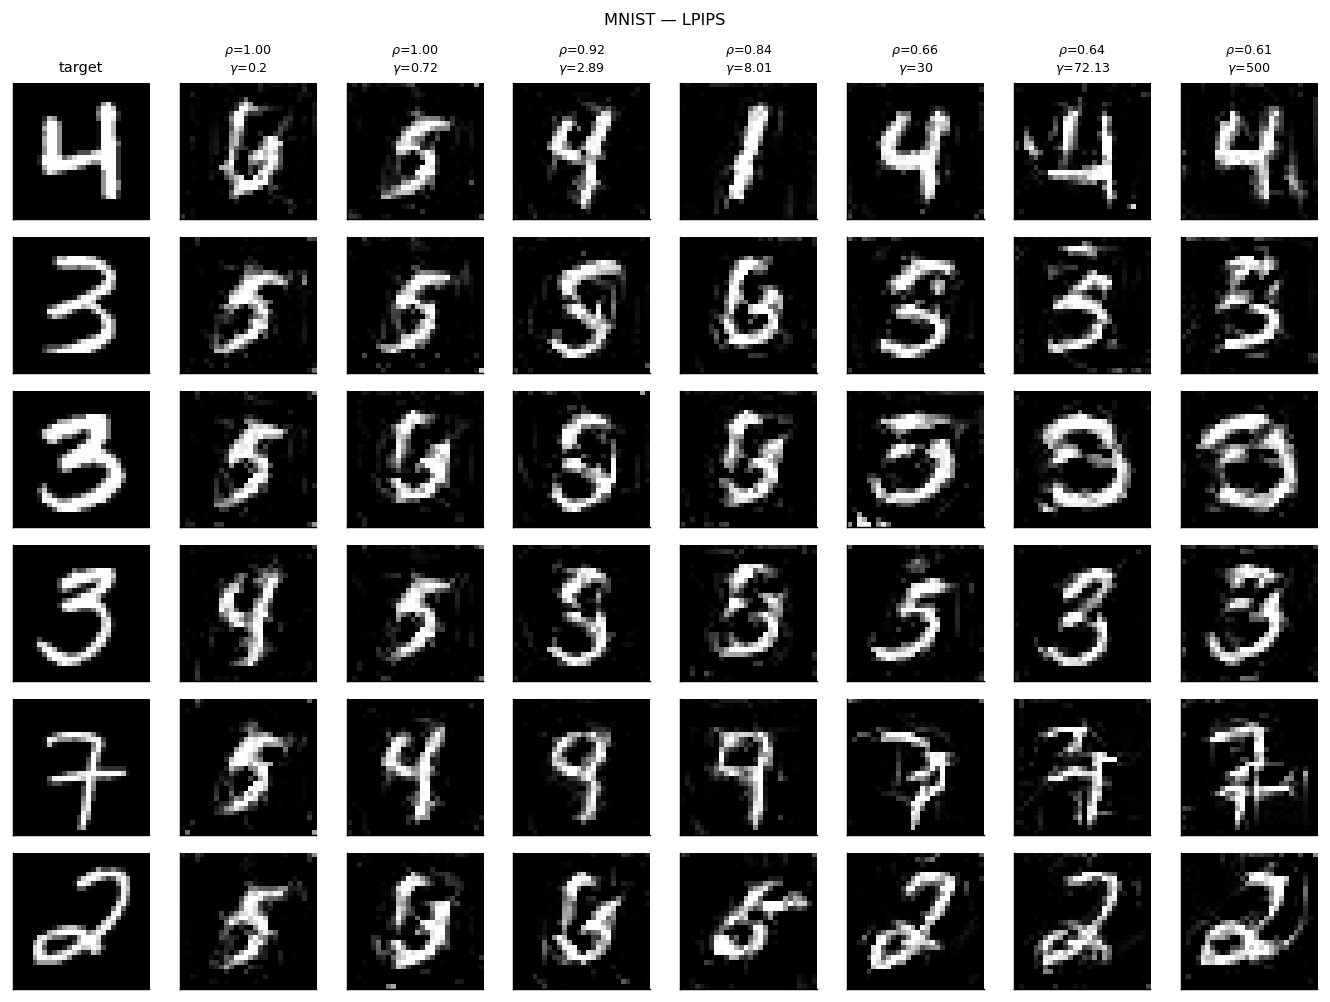

mnist lpips: gamma -> rho: 0.2->1.000, 0.72->0.999, 2.89->0.922, 8.01->0.845, 30->0.656, 72.13->0.636, 500->0.611  (ncand=58000)


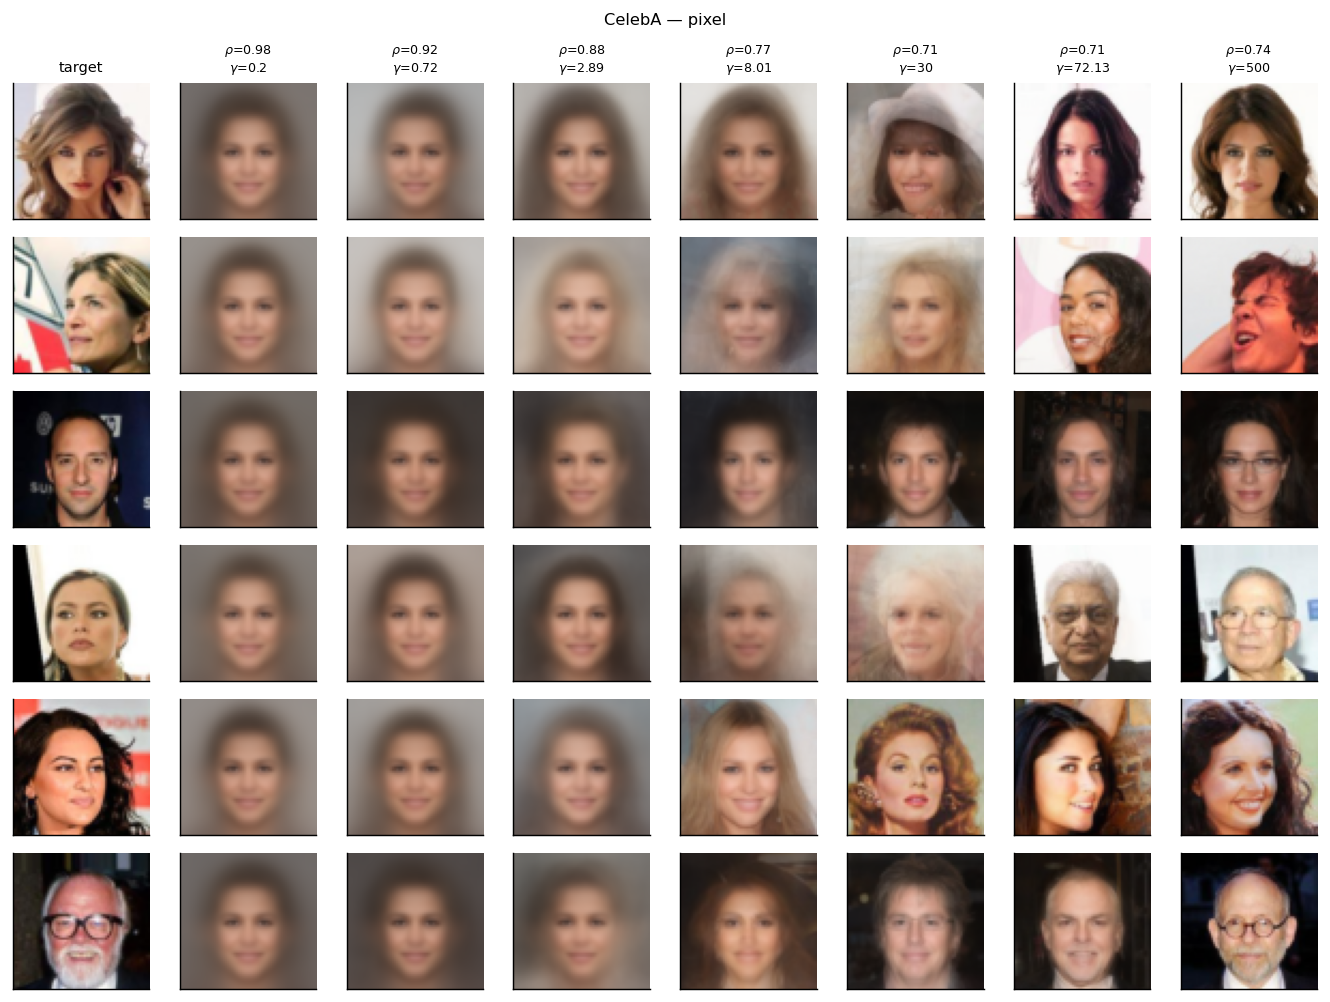

celeba pixel: gamma -> rho: 0.2->0.981, 0.72->0.920, 2.89->0.884, 8.01->0.768, 30->0.707, 72.13->0.707, 500->0.739  (ncand=44000)


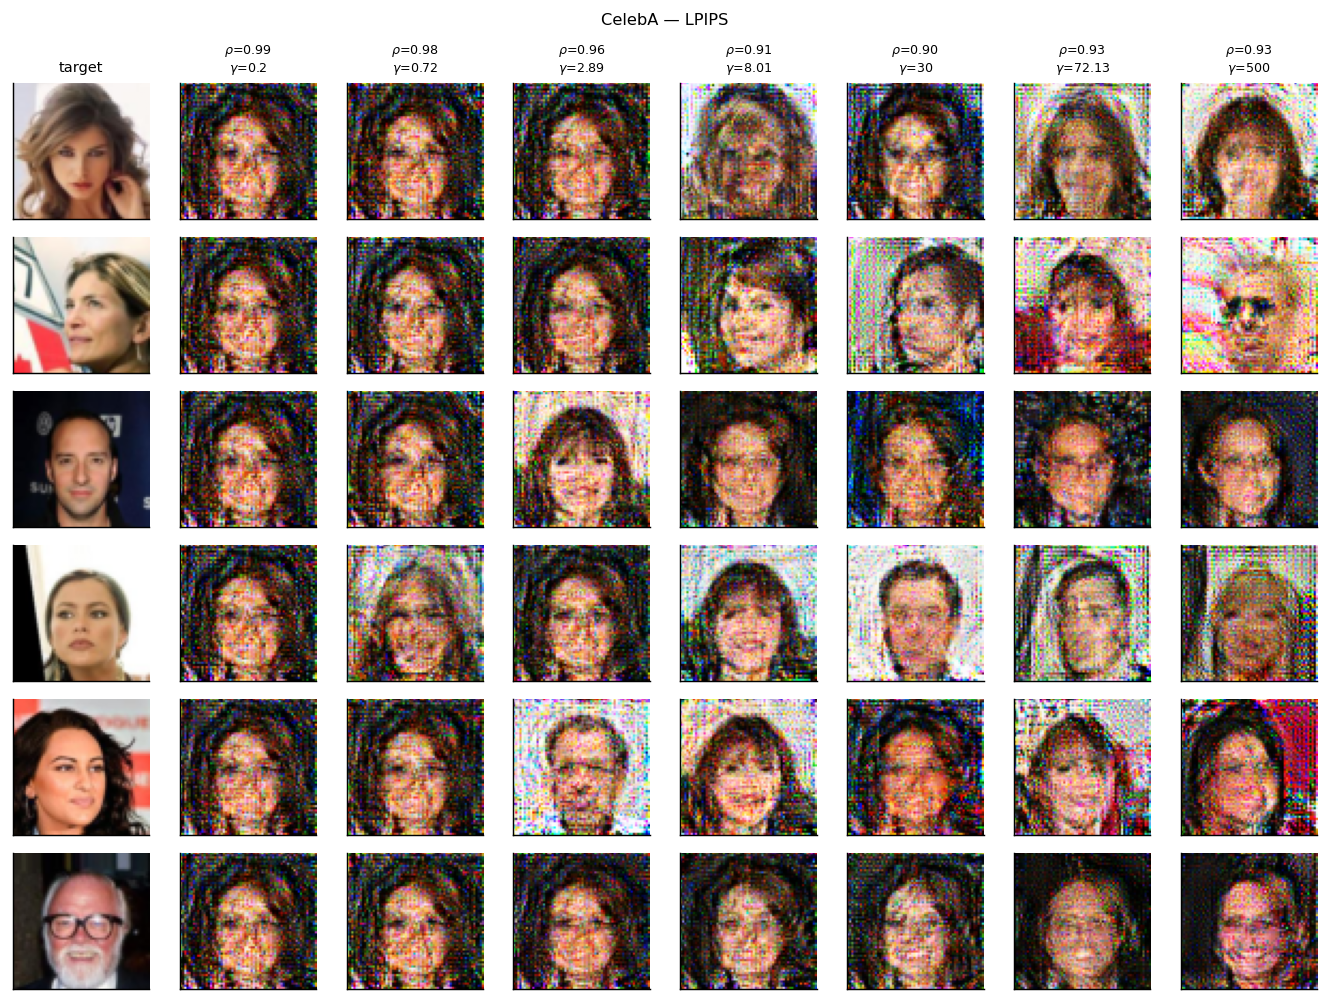

celeba lpips: gamma -> rho: 0.2->0.987, 0.72->0.983, 2.89->0.963, 8.01->0.911, 30->0.904, 72.13->0.933, 500->0.930  (ncand=44000)


In [11]:
def to_img(v, ds):
    v = np.clip(np.asarray(v, np.float32), 0, 1)
    return v.reshape(28, 28) if ds == "mnist" else v.reshape(3, 64, 64).transpose(1, 2, 0)

for ds, rep in [("mnist", "pixel"), ("mnist", "lpips"), ("celeba", "pixel"), ("celeba", "lpips")]:
    p = ROOT / f"results/tightness_spm/exemplars/exemplars_{ds}_{rep}.npz"
    if not p.exists(): print(f"MISSING {p} (run: bash reproduce/run_all.sh tightness)"); continue
    z = np.load(p); G, RHO, X, REC = z["gammas"], z["rho"], z["targets"], z["recon"]    # REC: (n_gamma, N, d)
    o = np.argsort(G); G, RHO, REC = G[o], RHO[o], REC[o]                             # columns: increasing leakage gamma
    N = X.shape[0]; fig, ax = plt.subplots(N, len(G) + 1, figsize=(1.3 * (len(G) + 1), 1.3 * N))
    for i in range(N):
        ax[i, 0].imshow(to_img(X[i], ds), cmap="gray" if ds == "mnist" else None, vmin=0, vmax=1)
        for j in range(len(G)):
            ax[i, j + 1].imshow(to_img(REC[j, i], ds), cmap="gray" if ds == "mnist" else None, vmin=0, vmax=1)
    for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
    ax[0, 0].set_title("target", fontsize=8)
    for j in range(len(G)): ax[0, j + 1].set_title(rf"$\rho$={RHO[j]:.2f}" + "\n" + rf"$\gamma$={G[j]:g}", fontsize=7)
    fig.suptitle(f"{PNAME[ds]} — {PNAME[rep]}", fontsize=9); fig.tight_layout()
    fig.savefig(FIG_DIR / f"tightness_exemplars_{ds}_{rep}.pdf", bbox_inches="tight"); plt.show()
    print(f"{ds} {rep}: gamma -> rho: " + ", ".join(f"{g:g}->{r:.3f}" for g, r in zip(G, RHO)) + f"  (ncand={int(z['ncand'])})")